In [ ]:
# نستورد pandas عشان نتعامل مع البيانات بشكل جدول (DataFrame)
import pandas as pd

# نستورد numpy عشان نولّد أرقام عشوائية (أسعار، كميات...) وقيم فارغة (NaN)
import numpy as np

# نستورد random عشان نختار عناصر عشوائية من قوائم (زي اختيار فئة منتج عشوائية)
import random

# نستورد datetime و timedelta عشان نولّد تواريخ منطقية ومتسلسلة
from datetime import datetime, timedelta

# نحدد "seed" ثابت للعشوائية، عشان كل مرة نشغل الكود تطلع نفس النتائج بالضبط
# هذا مهم جدًا للـ reproducibility (تكرار نفس التجربة) — ميزة يقدّرها أي مراجع لمشروعك
np.random.seed(42)
random.seed(42)

print("تم استيراد المكتبات بنجاح ✅")

تم استيراد المكتبات بنجاح ✅


In [ ]:
# قاموس (Dictionary) يربط كل فئة منتج بقائمة المنتجات اللي تنتمي لها
# استخدمنا قاموس عشان نضمن كل منتج يطلع بفئته الصحيحة لاحقًا
products_by_category = {
    "Phones": ["iPhone 14", "Samsung Galaxy S23", "Xiaomi Redmi Note 12", "Oppo Reno 8"],
    "Laptops": ["MacBook Air M2", "Dell XPS 13", "HP Pavilion 15", "Lenovo ThinkPad E14"],
    "Accessories": ["Wireless Mouse", "USB-C Cable", "Bluetooth Headphones", "Laptop Stand"],
    "TVs": ["Samsung 55-inch QLED", "LG 43-inch UHD", "Sony 65-inch Bravia"],
    "Cameras": ["Canon EOS 200D", "Nikon D3500", "GoPro Hero 11"]
}

# قائمة بطرق الدفع الممكنة
payment_methods = ["Credit Card", "Debit Card", "Cash on Delivery", "Apple Pay"]

# قائمة بالمناطق (Regions) اللي ممكن يكون فيها العملاء
regions = ["Riyadh", "Jeddah", "Dammam", "Makkah", "Madinah"]

# نطبع كل قائمة عشان نتأكد إنها انكتبت صح
print("فئات المنتجات:", list(products_by_category.keys()))
print("طرق الدفع:", payment_methods)
print("المناطق:", regions)

فئات المنتجات: ['Phones', 'Laptops', 'Accessories', 'TVs', 'Cameras']
طرق الدفع: ['Credit Card', 'Debit Card', 'Cash on Delivery', 'Apple Pay']
المناطق: ['Riyadh', 'Jeddah', 'Dammam', 'Makkah', 'Madinah']


In [ ]:
# نحدد عدد الطلبات (الصفوف) اللي بنولدها - اخترنا 4000 كحجم متوسط واقعي
num_orders = 4000

# نحدد نطاق التواريخ: من بداية 2024 إلى نهاية 2024 (سنة كاملة من المبيعات)
start_date = datetime(2024, 1, 1)
end_date = datetime(2024, 12, 31)
date_range_days = (end_date - start_date).days  # عدد الأيام بين التاريخين

# قائمة فاضية بنجمع فيها كل صف (كل طلب) قبل ما نحولها لجدول
orders_list = []

# حلقة تكرار تمر على عدد الطلبات اللي حددناها، كل مرة تبني "طلب" واحد
for i in range(num_orders):

    # نختار فئة منتج عشوائية من مفاتيح القاموس (Phones, Laptops...)
    category = random.choice(list(products_by_category.keys()))

    # نختار منتج عشوائي من داخل تلك الفئة تحديدًا (عشان يكون منطقي)
    product = random.choice(products_by_category[category])

    # نولّد تاريخ عشوائي بإضافة عدد أيام عشوائي على تاريخ البداية
    random_days = random.randint(0, date_range_days)
    order_date = start_date + timedelta(days=random_days)

    # نولّد سعر منطقي حسب الفئة (الجوالات واللابتوبات أغلى من الإكسسوارات مثلاً)
    if category == "Phones":
        unit_price = round(np.random.uniform(1500, 5000), 2)
    elif category == "Laptops":
        unit_price = round(np.random.uniform(2500, 9000), 2)
    elif category == "TVs":
        unit_price = round(np.random.uniform(1800, 7000), 2)
    elif category == "Cameras":
        unit_price = round(np.random.uniform(900, 4500), 2)
    else:  # Accessories
        unit_price = round(np.random.uniform(30, 400), 2)

    # نولّد كمية منطقية (غالبًا بين 1 و5 قطع بالطلب الواحد)
    quantity = random.randint(1, 5)

    # نختار طريقة دفع عشوائية من القائمة
    payment = random.choice(payment_methods)

    # نختار منطقة عشوائية من القائمة
    region = random.choice(regions)

    # نبني "صف" واحد على شكل قاموس، ونضيفه لقائمة الطلبات
    orders_list.append({
        "OrderID": 1000 + i,           # رقم طلب فريد يبدأ من 1000
        "OrderDate": order_date,
        "CustomerID": 5000 + random.randint(0, 800),  # نسمح بتكرار CustomerID (نفس العميل يشتري أكثر من مرة)
        "ProductCategory": category,
        "ProductName": product,
        "Quantity": quantity,
        "UnitPrice": unit_price,
        "PaymentMethod": payment,
        "Region": region
    })

# نحول القائمة الكاملة (Python List) إلى جدول بيانات (DataFrame) باستخدام pandas
df = pd.DataFrame(orders_list)

# نطبع أول 5 صفوف عشان نتأكد الجدول اتبنى صح
print("تم توليد الجدول بنجاح ✅")
print("عدد الصفوف:", len(df))
df.head()

تم توليد الجدول بنجاح ✅
عدد الصفوف: 4000


,OrderID,OrderDate,CustomerID,ProductCategory,ProductName,Quantity,UnitPrice,PaymentMethod,Region
0,1000,2024-05-20,5754,Phones,iPhone 14,2,2810.89,Debit Card,Jeddah
1,1001,2024-10-29,5095,Phones,iPhone 14,4,4827.50,Credit Card,Riyadh
2,1002,2024-09-15,5203,Laptops,Dell XPS 13,5,7257.96,Credit Card,Madinah
3,1003,2024-04-22,5777,Cameras,Nikon D3500,4,3055.17,Cash on Delivery,Riyadh
4,1004,2024-06-23,5781,Laptops,Lenovo ThinkPad E14,3,3514.12,Debit Card,Jeddah


In [ ]:
# نسوي نسخة من الجدول الأصلي النظيف عشان نحافظ عليه كمرجع (Ground Truth)
# ونشتغل التوسيخ على هذي النسخة الجديدة فقط
df_dirty = df.copy()

# --- 1) CustomerID: نفترض 5% من الطلبات كانت كـ "Guest" بدون حساب مسجل ---
# نختار عشوائيًا 5% من عدد الصفوف الكلي (بدون تكرار نفس الصف مرتين)
missing_customer_idx = df_dirty.sample(frac=0.05, random_state=1).index
# نحط قيمة NaN (فارغة) في تلك الصفوف بعمود CustomerID تحديدًا
df_dirty.loc[missing_customer_idx, "CustomerID"] = np.nan

# --- 2) PaymentMethod: نفترض 3% من الطلبات صار فيها خطأ تقني ما سجل طريقة الدفع ---
missing_payment_idx = df_dirty.sample(frac=0.03, random_state=2).index
df_dirty.loc[missing_payment_idx, "PaymentMethod"] = np.nan

# --- 3) Region: نفترض 4% من العملاء ما حددوا منطقتهم عند الطلب ---
missing_region_idx = df_dirty.sample(frac=0.04, random_state=3).index
df_dirty.loc[missing_region_idx, "Region"] = np.nan

# نطبع تقرير سريع: كم قيمة فاضية صارت بكل عمود
print("تم حقن القيم المفقودة بنجاح ✅")
print("\nعدد القيم المفقودة بكل عمود:")
print(df_dirty.isnull().sum())

تم حقن القيم المفقودة بنجاح ✅

عدد القيم المفقودة بكل عمود:
OrderID              0
OrderDate            0
CustomerID         200
ProductCategory      0
ProductName          0
Quantity             0
UnitPrice            0
PaymentMethod      120
Region             160
dtype: int64


In [ ]:
# --- نضيف صفوف مكررة بالكامل (نسخة طبق الأصل من صفوف موجودة) ---

# نختار عشوائيًا 60 صف من الجدول الحالي (df_dirty) عشان نكررهم
rows_to_duplicate = df_dirty.sample(n=60, random_state=4)

# ندمج الجدول الأصلي مع نسخة إضافية من تلك الصفوف المختارة
# ignore_index=True يعيد ترقيم الصفوف من جديد بعد الدمج (بدل ما تتكرر الفهرسة)
df_dirty = pd.concat([df_dirty, rows_to_duplicate], ignore_index=True)

# نطبع تقرير: كم صف صار عندنا الحين، وكم صف مكرر بالضبط (duplicated)
print("تم إضافة الصفوف المكررة بنجاح ✅")
print("عدد الصفوف الكلي الآن:", len(df_dirty))
print("عدد الصفوف المكررة بالكامل:", df_dirty.duplicated().sum())

تم إضافة الصفوف المكررة بنجاح ✅
عدد الصفوف الكلي الآن: 4060
عدد الصفوف المكررة بالكامل: 60


In [ ]:
# --- نحول عمود OrderDate لنص (str) في بعض الصفوف بصيغ مختلفة عمدًا ---

import numpy as np

# دالة تاخذ تاريخ (datetime) وتحوله لنص بصيغة عشوائية من 4 صيغ مختلفة
def randomize_date_format(date_value):
    fmt_choice = random.choice([1, 2, 3, 4])
    if fmt_choice == 1:
        return date_value.strftime("%Y-%m-%d")          # 2024-05-20
    elif fmt_choice == 2:
        return date_value.strftime("%d/%m/%Y")           # 20/05/2024
    elif fmt_choice == 3:
        return date_value.strftime("%m-%d-%Y")           # 05-20-2024
    else:
        return date_value.strftime("%B %d, %Y")          # May 20, 2024

# نختار عشوائيًا 25% من الصفوف عشان نغيّر صيغة تاريخها (الباقي يضل بصيغة datetime عادية)
mixed_format_idx = df_dirty.sample(frac=0.25, random_state=5).index

# نطبق الدالة على تلك الصفوف بالذات، ونحول القيمة الناتجة لنص (string) بدل تاريخ
df_dirty.loc[mixed_format_idx, "OrderDate"] = df_dirty.loc[mixed_format_idx, "OrderDate"].apply(randomize_date_format)

# نطبع عينة من العمود عشان نشوف التنوع بالصيغ (نطبع 10 قيم عشوائية)
print("تم خلط تنسيقات التواريخ بنجاح ✅")
print("\nعينة من عمود OrderDate:")
print(df_dirty["OrderDate"].sample(10, random_state=6))

# نطبع نوع البيانات (dtype) بعمود OrderDate عشان نلاحظ إنه صار "object" (نص مختلط) بدل تاريخ صافي
print("\nنوع العمود الآن:", df_dirty["OrderDate"].dtype)

تم خلط تنسيقات التواريخ بنجاح ✅

عينة من عمود OrderDate:
631    2024-01-24
1135   2024-12-17
2284   2024-12-01
3222   2024-02-25
1171   2024-06-19
1222   2024-12-10
3392   2024-02-29
2843   2024-09-11
3091   2024-03-02
3108   2024-01-18
Name: OrderDate, dtype: datetime64[ns]

نوع العمود الآن: datetime64[ns]


In [ ]:
# نطبع أنواع البيانات (types) الفعلية لأول 15 قيمة بعمود OrderDate
# عشان نتأكد هل هي فعلاً كلها Timestamp، ولا فيها نصوص (str) بينها
for value in df_dirty["OrderDate"].head(15):
    print(value, "->", type(value))

2024-05-20 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-10-29 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-09-15 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-04-22 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-06-23 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-02-17 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-01-23 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-11-17 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-12-04 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-05-22 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-12-09 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-03-24 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-12-16 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-05-17 00:00:00 -> <class 'pandas.

In [ ]:
# أولاً، نحول عمود OrderDate بالكامل إلى نوع نصي (string) بشكل صريح
# هذا يمنع pandas من "تفسير" القيم تلقائيًا كتواريخ لاحقًا
df_dirty["OrderDate"] = df_dirty["OrderDate"].astype(object)

# الآن نعيد تطبيق نفس الدالة على نفس الصفوف المختارة سابقًا
df_dirty.loc[mixed_format_idx, "OrderDate"] = df_dirty.loc[mixed_format_idx, "OrderDate"].apply(randomize_date_format)

# نتأكد الآن من النوع الفعلي لأول 15 قيمة
print("تم تصحيح المشكلة، النتيجة الجديدة:\n")
for value in df_dirty["OrderDate"].head(15):
    print(value, "->", type(value))

print("\nنوع العمود بالكامل الآن:", df_dirty["OrderDate"].dtype)

تم تصحيح المشكلة، النتيجة الجديدة:

May 20, 2024 -> <class 'str'>
2024-10-29 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-09-15 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-04-22 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-06-23 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-02-17 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
January 23, 2024 -> <class 'str'>
2024-11-17 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-12-04 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
22/05/2024 -> <class 'str'>
2024-12-09 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-03-24 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
12-16-2024 -> <class 'str'>
2024-05-17 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>
2024-12-01 00:00:00 -> <class 'pandas._libs.tslibs.timestamps.Timestamp'>

نوع العمود بالكامل الآن: obje

In [ ]:
# --- نسوي نسخة "وسخة" من قيم عمود ProductCategory بمشكلتين: أخطاء إملائية + مسافات زايدة ---

# قاموس يربط كل فئة أصلية بقائمة "بدائل وسخة" ممكنة لها
dirty_category_variants = {
    "Phones": ["phones", "Phone", " Phones", "PHONES", "Phones "],
    "Laptops": ["laptops", "Laptop", " Laptops", "LAPTOPS"],
    "Accessories": ["accessories", "Accessory", " Accessories ", "ACCESSORIES"],
    "TVs": ["tvs", "TV", " TVs", "Tvs "],
    "Cameras": ["cameras", "Camera", " Cameras", "CAMERAS "]
}

# نختار عشوائيًا 20% من الصفوف عشان نغيّر صيغة الفئة فيها
messy_category_idx = df_dirty.sample(frac=0.20, random_state=7).index

# دالة تاخذ الفئة الأصلية وترجع بديل "وسخ" عشوائي من قائمتها
def make_messy_category(category_value):
    variants = dirty_category_variants[category_value]
    return random.choice(variants)

# نطبق الدالة بس على الصفوف المختارة
df_dirty.loc[messy_category_idx, "ProductCategory"] = df_dirty.loc[messy_category_idx, "ProductCategory"].apply(make_messy_category)

# نطبع كل القيم الفريدة (Unique) الموجودة الآن بعمود ProductCategory
print("تم توسيخ الفئات بنجاح ✅")
print("\nكل القيم الفريدة بعمود ProductCategory الآن:")
print(df_dirty["ProductCategory"].unique())

تم توسيخ الفئات بنجاح ✅

كل القيم الفريدة بعمود ProductCategory الآن:
['Phones' 'LAPTOPS' 'Cameras' 'Laptops' 'Accessories' ' Phones' 'TVs'
 'laptops' 'Accessory' ' Cameras' 'ACCESSORIES' 'Camera' 'Laptop'
 'accessories' 'Phones ' ' TVs' 'TV' ' Laptops' 'tvs' ' Accessories '
 'CAMERAS ' 'phones' 'Phone' 'PHONES' 'cameras' 'Tvs ']


In [ ]:
# --- نحول جزء من الصفوف إلى "مرتجعات" بجعل الكمية سالبة ---

# نختار عشوائيًا 6% من الصفوف عشان تمثل عمليات إرجاع (نسبة واقعية لمعدل المرتجعات بالتجارة الإلكترونية)
returns_idx = df_dirty.sample(frac=0.06, random_state=8).index

# نحول قيمة الكمية بتلك الصفوف إلى سالبة (لو كانت 3، تصير -3)
# نستخدم علامة السالب (-) مباشرة على القيمة الموجودة، بدل ما نولّد رقم جديد
df_dirty.loc[returns_idx, "Quantity"] = df_dirty.loc[returns_idx, "Quantity"] * -1

# نطبع تقرير: كم عملية إرجاع صار عندنا، وعينة منها
print("تم إضافة المرتجعات (كميات سالبة) بنجاح ✅")
print("\nعدد الصفوف اللي فيها كمية سالبة:", (df_dirty["Quantity"] < 0).sum())

print("\nعينة من صفوف المرتجعات:")
print(df_dirty[df_dirty["Quantity"] < 0][["OrderID", "ProductName", "Quantity"]].head(8))

تم إضافة المرتجعات (كميات سالبة) بنجاح ✅

عدد الصفوف اللي فيها كمية سالبة: 244

عينة من صفوف المرتجعات:
     OrderID           ProductName  Quantity
15      1015           USB-C Cable        -5
48      1048           USB-C Cable        -5
51      1051        Canon EOS 200D        -2
64      1064        Wireless Mouse        -5
70      1070           Nikon D3500        -5
86      1086         GoPro Hero 11        -5
91      1091  Samsung 55-inch QLED        -2
109     1109        LG 43-inch UHD        -1


In [ ]:
# --- نضيف قيم شاذة (Outliers) بعمود UnitPrice ---

# 1) أسعار عالية جدًا بشكل غير منطقي (نفترض خطأ موظف أضاف صفر زيادة للسعر)
# نختار عشوائيًا 1% من الصفوف فقط (الـ Outliers نادرة بطبيعتها، مو شائعة)
extreme_high_idx = df_dirty.sample(frac=0.01, random_state=9).index
# نضرب السعر الأصلي في رقم عشوائي كبير (بين 15 و30) عشان يطلع سعر غير منطقي
df_dirty.loc[extreme_high_idx, "UnitPrice"] = df_dirty.loc[extreme_high_idx, "UnitPrice"] * np.random.uniform(15, 30)

# 2) أسعار صفر أو سالبة (خطأ نظام وقت تسجيل السعر)
zero_negative_idx = df_dirty.sample(frac=0.005, random_state=10).index
# نستبدل القيمة بقيمة عشوائية بين -50 و 0 (يعني إما صفر أو سالب بسيط)
df_dirty.loc[zero_negative_idx, "UnitPrice"] = np.round(np.random.uniform(-50, 0, size=len(zero_negative_idx)), 2)

# نطبع إحصائية سريعة (min, max, mean) عشان نشوف أثر الـ Outliers بوضوح
print("تم إضافة القيم الشاذة بالأسعار بنجاح ✅")
print("\nإحصائية عمود UnitPrice الآن:")
print(df_dirty["UnitPrice"].describe())

تم إضافة القيم الشاذة بالأسعار بنجاح ✅

إحصائية عمود UnitPrice الآن:
count      4060.000000
mean       4051.619678
std       10585.455958
min         -48.270000
25%        1563.345000
50%        3208.000000
75%        4623.830000
max      210105.973710
Name: UnitPrice, dtype: float64


In [ ]:
# --- نضيف مسافات زايدة (بالبداية والنهاية) لأسماء بعض المنتجات ---

# نختار عشوائيًا 15% من الصفوف عشان نضيف لها مسافات زايدة باسم المنتج
extra_space_idx = df_dirty.sample(frac=0.15, random_state=11).index

# دالة بسيطة تضيف مسافات عشوائية (بين 1 و3) في بداية أو نهاية النص، أو الاثنين مع بعض
def add_extra_spaces(text_value):
    style = random.choice(["before", "after", "both"])
    spaces = " " * random.randint(1, 3)
    if style == "before":
        return spaces + text_value
    elif style == "after":
        return text_value + spaces
    else:
        return spaces + text_value + spaces

# نطبق الدالة على الصفوف المختارة بعمود ProductName
df_dirty.loc[extra_space_idx, "ProductName"] = df_dirty.loc[extra_space_idx, "ProductName"].apply(add_extra_spaces)

# نطبع عينة نستخدم فيها أقواس [] عشان نشوف المسافات بوضوح (وإلا العين ما تلاحظها بسهولة)
print("تم إضافة المسافات الزايدة بنجاح ✅")
print("\nعينة توضح المسافات (بين أقواس []):")
for name in df_dirty.loc[extra_space_idx, "ProductName"].head(8):
    print(f"[{name}]")

تم إضافة المسافات الزايدة بنجاح ✅

عينة توضح المسافات (بين أقواس []):
[  Nikon D3500]
[Samsung Galaxy S23  ]
[Xiaomi Redmi Note 12 ]
[ LG 43-inch UHD]
[Nikon D3500   ]
[LG 43-inch UHD  ]
[ Laptop Stand]
[   Laptop Stand   ]


In [ ]:
# نستورد مكتبة os عشان نقدر نتعامل مع المجلدات (نسوي مجلد لو مو موجود أصلاً)
import os

# نحدد مسار المجلد اللي بنحفظ فيه المشروع داخل قوقل درايف
project_folder = "/content/drive/MyDrive/Ecommerce_Sales_Analytics_Project"

# نتأكد المجلد موجود، ولو مو موجود ننشئه تلقائيًا (exist_ok=True يمنع الخطأ لو كان موجود أصلاً)
os.makedirs(project_folder, exist_ok=True)

# نحفظ ملف الـ CSV مباشرة داخل هذا المجلد
save_path = os.path.join(project_folder, "ecommerce_sales_dirty.csv")
df_dirty.to_csv(save_path, index=False)

# نتأكد من نجاح الحفظ
file_size_kb = os.path.getsize(save_path) / 1024
print("تم إنشاء المجلد وحفظ الملف بنجاح ✅")
print(f"مسار الملف: {save_path}")
print(f"حجم الملف: {file_size_kb:.1f} KB")
print(f"عدد الصفوف: {len(df_dirty)}")

تم إنشاء المجلد وحفظ الملف بنجاح ✅
مسار الملف: /content/drive/MyDrive/Ecommerce_Sales_Analytics_Project/ecommerce_sales_dirty.csv
حجم الملف: 328.2 KB
عدد الصفوف: 4060


In [ ]:
# نستورد المكتبات اللي بنحتاجها لمرحلة التنظيف
import pandas as pd
import numpy as np

# (حذفنا سطرين ربط Drive لأنه مربوط أصلاً من قبل بنفس الجلسة)

# نحدد مسار الملف اللي حفظناه بالخطوة السابقة
file_path = "/content/drive/MyDrive/Ecommerce_Sales_Analytics_Project/ecommerce_sales_dirty.csv"

# نقرأ الملف من جديد كـ DataFrame طازج، ونسميه df (اسم جديد نظيف لمرحلة التنظيف)
df = pd.read_csv(file_path)

# نتأكد من نجاح القراءة بطباعة معلومات أساسية
print("تم تحميل البيانات بنجاح ✅")
print(f"عدد الصفوف: {len(df)}")
print(f"عدد الأعمدة: {len(df.columns)}")
print("\nأول 5 صفوف:")
df.head()

تم تحميل البيانات بنجاح ✅
عدد الصفوف: 4060
عدد الأعمدة: 9

أول 5 صفوف:


,OrderID,OrderDate,CustomerID,ProductCategory,ProductName,Quantity,UnitPrice,PaymentMethod,Region
0,1000,"May 20, 2024",5754.0,Phones,iPhone 14,2,2810.89,Debit Card,Jeddah
1,1001,2024-10-29 00:00:00,5095.0,Phones,iPhone 14,4,4827.50,Credit Card,Riyadh
2,1002,2024-09-15 00:00:00,5203.0,LAPTOPS,Dell XPS 13,5,7257.96,Credit Card,Madinah
3,1003,2024-04-22 00:00:00,5777.0,Cameras,Nikon D3500,4,3055.17,Cash on Delivery,Riyadh
4,1004,2024-06-23 00:00:00,5781.0,Laptops,Lenovo ThinkPad E14,3,3514.12,Debit Card,Jeddah


In [ ]:
# نطبع محتويات مجلد MyDrive بالكامل عشان نشوف وش فيه فعليًا من داخل Colab نفسه
import os

my_drive_path = "/content/drive/MyDrive"
print("محتويات My Drive من داخل Colab:\n")
for item in os.listdir(my_drive_path):
    print("-", item)

محتويات My Drive من داخل Colab:

- Ecommerce_Sales_Analytics_Project


In [ ]:
# --- فحص شامل أولي للبيانات قبل أي تعديل ---

# 1) معلومات عامة عن الأعمدة وأنواع بياناتها
print("=" * 50)
print("معلومات عامة عن الأعمدة (info):")
print("=" * 50)
df.info()

# 2) عدد القيم المفقودة بكل عمود
print("\n" + "=" * 50)
print("عدد القيم المفقودة بكل عمود:")
print("=" * 50)
print(df.isnull().sum())

# 3) عدد الصفوف المكررة بالكامل
print("\n" + "=" * 50)
print("عدد الصفوف المكررة بالكامل:", df.duplicated().sum())

# 4) القيم الفريدة بعمود الفئة (عشان نشوف كل النسخ الوسخة)
print("\n" + "=" * 50)
print("القيم الفريدة بعمود ProductCategory:")
print(df["ProductCategory"].unique())

# 5) إحصائية سريعة عن الأعمدة الرقمية (تكشف الـ Outliers)
print("\n" + "=" * 50)
print("إحصائية الأعمدة الرقمية:")
print(df.describe())

معلومات عامة عن الأعمدة (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4060 entries, 0 to 4059
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          4060 non-null   int64  
 1   OrderDate        4060 non-null   object 
 2   CustomerID       3857 non-null   float64
 3   ProductCategory  4060 non-null   object 
 4   ProductName      4060 non-null   object 
 5   Quantity         4060 non-null   int64  
 6   UnitPrice        4060 non-null   float64
 7   PaymentMethod    3938 non-null   object 
 8   Region           3896 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 285.6+ KB

عدد القيم المفقودة بكل عمود:
OrderID              0
OrderDate            0
CustomerID         203
ProductCategory      0
ProductName          0
Quantity             0
UnitPrice            0
PaymentMethod      122
Region             164
dtype: int64

عدد الصفوف المكررة بالكامل: 12

القيم الف

In [ ]:
# --- الخطوة 1: التعامل مع الصفوف المكررة بالكامل ---

# نعرض الصفوف المكررة أولاً (قبل الحذف) عشان نتأكد بأعيننا إنها فعلاً متطابقة
# keep=False يعرض كل نسخ التكرار (الأصل والمكرر) مو بس واحد منهم
duplicate_rows = df[df.duplicated(keep=False)]
print("عدد صفوف التكرار الظاهرة (أصل + نسخة):", len(duplicate_rows))
print("\nعينة من الصفوف المكررة (مرتبة بجانب بعض للمقارنة):")
print(duplicate_rows.sort_values(by="OrderID").head(10))

# الآن نحذف التكرار فعليًا - نحتفظ بأول نسخة بس ونحذف الباقي
# keep='first' يحتفظ بأول ظهور للصف ويحذف أي تكرار بعده
df = df.drop_duplicates(keep='first')

# نتأكد من النتيجة
print("\n" + "=" * 50)
print("تم حذف التكرار التام بنجاح ✅")
print("عدد الصفوف بعد الحذف:", len(df))
print("عدد الصفوف المكررة المتبقية:", df.duplicated().sum())

عدد صفوف التكرار الظاهرة (أصل + نسخة): 24

عينة من الصفوف المكررة (مرتبة بجانب بعض للمقارنة):
      OrderID            OrderDate  CustomerID ProductCategory  \
491      1491  2024-10-29 00:00:00      5778.0             TVs   
4004     1491  2024-10-29 00:00:00      5778.0             TVs   
671      1671  2024-11-06 00:00:00      5390.0     Accessories   
4036     1671  2024-11-06 00:00:00      5390.0     Accessories   
4052     2219           12-23-2024      5294.0     Accessories   
1219     2219           12-23-2024      5294.0     Accessories   
1646     2646  2024-12-03 00:00:00      5101.0             TVs   
4058     2646  2024-12-03 00:00:00      5101.0             TVs   
4054     3261  2024-03-10 00:00:00      5153.0          Phones   
2261     3261  2024-03-10 00:00:00      5153.0          Phones   

               ProductName  Quantity  UnitPrice     PaymentMethod   Region  
491         LG 43-inch UHD         4    5024.69        Debit Card  Madinah  
4004        LG 43-inch UH

In [ ]:
# --- الخطوة 2: تنظيف عمود ProductCategory ---

# أولاً: نشوف كل القيم الفريدة الحالية عشان نبني خارطة التصحيح
print("القيم الحالية قبل التنظيف:")
print(sorted(df["ProductCategory"].unique()))

# الخطوة أ: نشيل المسافات الزايدة من البداية والنهاية لكل قيمة نصية
# .str.strip() يشيل المسافات بس من الطرفين (مو من النص بالنص)
df["ProductCategory"] = df["ProductCategory"].str.strip()

# الخطوة ب: نوحّد حالة الأحرف - نخلي أول حرف كبير والباقي صغير (Title Case)
# .str.title() تحول "PHONES" و"phones" كلهم لـ "Phones"
df["ProductCategory"] = df["ProductCategory"].str.title()

# نتأكد من النتيجة بعد أول معالجتين
print("\nالقيم بعد إزالة المسافات وتوحيد حالة الأحرف:")
print(sorted(df["ProductCategory"].unique()))

القيم الحالية قبل التنظيف:
[' Accessories ', ' Cameras', ' Laptops', ' Phones', ' TVs', 'ACCESSORIES', 'Accessories', 'Accessory', 'CAMERAS ', 'Camera', 'Cameras', 'LAPTOPS', 'Laptop', 'Laptops', 'PHONES', 'Phone', 'Phones', 'Phones ', 'TV', 'TVs', 'Tvs ', 'accessories', 'cameras', 'laptops', 'phones', 'tvs']

القيم بعد إزالة المسافات وتوحيد حالة الأحرف:
['Accessories', 'Accessory', 'Camera', 'Cameras', 'Laptop', 'Laptops', 'Phone', 'Phones', 'Tv', 'Tvs']


In [ ]:
# --- الخطوة ج: تصحيح أخطاء الإفراد/الجمع عبر خارطة تحويل (Mapping) ---

# نبني قاموس يربط كل قيمة "خاطئة" بالقيمة "الصحيحة" الموحدة اللي نبيها
category_corrections = {
    "Accessory": "Accessories",
    "Camera": "Cameras",
    "Laptop": "Laptops",
    "Phone": "Phones",
    "Tv": "TVs",      # نلاحظ هنا: نصحح الحالة كمان (TVs بحرفين كبار، مو Tvs)
    "Tvs": "TVs"      # نفس الملاحظة - نوحد الاختصار TV بشكل صحيح
}

# .replace() يبحث عن أي قيمة موجودة بالقاموس (المفتاح) ويستبدلها بالقيمة المقابلة له
df["ProductCategory"] = df["ProductCategory"].replace(category_corrections)

# نتأكد من النتيجة النهائية
print("القيم النهائية بعد كل التصحيحات:")
print(sorted(df["ProductCategory"].unique()))

print("\nعدد القيم الفريدة النهائي:", df["ProductCategory"].nunique())

# نطبع كم عدد الطلبات بكل فئة، للتأكد إن الفئات توزعت بشكل منطقي
print("\nتوزيع الطلبات على الفئات:")
print(df["ProductCategory"].value_counts())

القيم النهائية بعد كل التصحيحات:
['Accessories', 'Cameras', 'Laptops', 'Phones', 'TVs']

عدد القيم الفريدة النهائي: 5

توزيع الطلبات على الفئات:
ProductCategory
Phones         845
Cameras        818
Accessories    801
Laptops        794
TVs            790
Name: count, dtype: int64


In [ ]:
# --- الخطوة 3: توحيد تنسيقات عمود OrderDate ---

# نحدد كل الصيغ المحتملة اللي وسخنا فيها العمود، بترتيب معين
possible_formats = [
    "%Y-%m-%d %H:%M:%S",  # الصيغة الأصلية غير المعدلة (بعد قراءتها من CSV كنص)
    "%Y-%m-%d",             # ISO: 2024-05-20
    "%d/%m/%Y",             # يوم/شهر/سنة: 20/05/2024
    "%m-%d-%Y",             # شهر-يوم-سنة: 05-20-2024
    "%B %d, %Y"             # نص كامل: May 20, 2024
]

# دالة تاخذ قيمة تاريخ نصية وتجرب كل صيغة بالترتيب لحد ما توفق
def parse_mixed_date(date_str):
    for fmt in possible_formats:
        try:
            # نحاول تحويل القيمة بهذي الصيغة المحددة
            return pd.to_datetime(date_str, format=fmt)
        except (ValueError, TypeError):
            # لو ما نجحت هذي الصيغة، نكمل نجرب اللي بعدها
            continue
    # لو ما وفقت ولا صيغة، نرجع NaT (تاريخ فارغ/غير صالح) بدل ما يوقف الكود بخطأ
    return pd.NaT

# نطبق الدالة على كل قيمة بعمود OrderDate
df["OrderDate"] = df["OrderDate"].apply(parse_mixed_date)

# نتأكد من النتيجة
print("تم توحيد صيغة التواريخ بنجاح ✅")
print("\nنوع العمود الآن:", df["OrderDate"].dtype)

تم توحيد صيغة التواريخ بنجاح ✅

نوع العمود الآن: datetime64[ns]


In [ ]:
# --- الخطوة 4: معالجة القيم المفقودة ---

# 1) CustomerID: نعبي القيم الفاضية بـ "Guest" (تمثل طلبات بدون تسجيل حساب)
# نحول العمود لنوع نصي (string) أولاً، لأنه حاليًا float64 بسبب الـ NaN
df["CustomerID"] = df["CustomerID"].astype(str)
# نستبدل قيمة "nan" النصية (اللي نتجت من التحويل) بكلمة "Guest"
df["CustomerID"] = df["CustomerID"].replace("nan", "Guest")

# 2) PaymentMethod: نعبي القيم الفاضية بـ "Unknown" (ما نقدر نخمّن طريقة الدفع الفعلية)
df["PaymentMethod"] = df["PaymentMethod"].fillna("Unknown")

# 3) Region: نعبي القيم الفاضية بـ "Not Specified"
df["Region"] = df["Region"].fillna("Not Specified")

# نتأكد من النتيجة النهائية - ما لازم يبقى أي قيمة مفقودة بكل الجدول
print("تم معالجة القيم المفقودة بنجاح ✅")
print("\nعدد القيم المفقودة المتبقية بكل عمود:")
print(df.isnull().sum())

# نطبع عينة من الصفوف اللي كانت فيها قيم مفقودة، للتأكد بصريًا
print("\nعينة من الصفوف اللي فيها 'Guest' أو 'Unknown' أو 'Not Specified':")
print(df[(df["CustomerID"] == "Guest") | (df["PaymentMethod"] == "Unknown") | (df["Region"] == "Not Specified")].head(5))

تم معالجة القيم المفقودة بنجاح ✅

عدد القيم المفقودة المتبقية بكل عمود:
OrderID            0
OrderDate          0
CustomerID         0
ProductCategory    0
ProductName        0
Quantity           0
UnitPrice          0
PaymentMethod      0
Region             0
dtype: int64

عينة من الصفوف اللي فيها 'Guest' أو 'Unknown' أو 'Not Specified':
    OrderID  OrderDate CustomerID ProductCategory          ProductName  \
6      1006 2024-01-23      Guest         Cameras          Nikon D3500   
17     1017 2024-02-26      Guest          Phones            iPhone 14   
30     1030 2024-12-08     5135.0         Laptops       HP Pavilion 15   
45     1045 2024-05-15     5468.0     Accessories          USB-C Cable   
72     1072 2024-04-19     5674.0             TVs  Sony 65-inch Bravia   

    Quantity  UnitPrice PaymentMethod         Region  
6          4    1109.10   Credit Card  Not Specified  
17         2    3336.65    Debit Card         Makkah  
30         4    6449.04       Unknown        Madi

In [ ]:
# --- تحسين إضافي: نشيل الـ ".0" الزايدة من أرقام CustomerID الحقيقية ---

# دالة تشيل ".0" من نهاية أي رقم عميل حقيقي، وتترك "Guest" زي ما هي
def clean_customer_id(value):
    if value == "Guest":
        return value
    # نحول القيمة لرقم عشري float، ثم لرقم صحيح int، ثم لنص - يشيل أي ".0" زايدة
    return str(int(float(value)))

# نطبق الدالة على كل قيم عمود CustomerID
df["CustomerID"] = df["CustomerID"].apply(clean_customer_id)

# نتأكد من النتيجة
print("تم تحسين شكل CustomerID بنجاح ✅")
print(df[df["CustomerID"] != "Guest"]["CustomerID"].head(5))

تم تحسين شكل CustomerID بنجاح ✅
0    5754
1    5095
2    5203
3    5777
4    5781
Name: CustomerID, dtype: object


In [ ]:
# --- الخطوة 5: التعامل مع الكميات السالبة (المرتجعات) بذكاء ---

# 1) نضيف عمود جديد يوضح نوع الطلب: "Return" لو الكمية سالبة، "Sale" لو موجبة
# np.where(condition, value_if_true, value_if_false) هي دالة شرطية سريعة تعمل على العمود كامل دفعة وحدة
df["OrderType"] = np.where(df["Quantity"] < 0, "Return", "Sale")

# 2) نحسب عمود المبلغ الكلي لكل طلب = الكمية × سعر الوحدة
# بما إن الكمية سالبة بالمرتجعات، الناتج بيطلع سالب تلقائيًا (منطقي: مرتجع = خصم من الإيراد)
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# نتأكد من النتيجة
print("تم إضافة عمودي OrderType و TotalAmount بنجاح ✅")

print("\nتوزيع أنواع الطلبات:")
print(df["OrderType"].value_counts())

print("\nعينة من صفوف المرتجعات (Return) للتأكد من صحة الحساب:")
print(df[df["OrderType"] == "Return"][["OrderID", "ProductName", "Quantity", "UnitPrice", "TotalAmount"]].head(5))

تم إضافة عمودي OrderType و TotalAmount بنجاح ✅

توزيع أنواع الطلبات:
OrderType
Sale      3804
Return     244
Name: count, dtype: int64

عينة من صفوف المرتجعات (Return) للتأكد من صحة الحساب:
    OrderID     ProductName  Quantity  UnitPrice  TotalAmount
15     1015     USB-C Cable        -5      97.86      -489.30
48     1048     USB-C Cable        -5     232.28     -1161.40
51     1051  Canon EOS 200D        -2    3690.48     -7380.96
64     1064  Wireless Mouse        -5     -11.99        59.95
70     1070     Nikon D3500        -5    3680.08    -18400.40


In [ ]:
# --- الخطوة 6: معالجة القيم الشاذة (Outliers) بعمود UnitPrice ---

# 1) نحسب الوسيط (median) لسعر كل فئة على حدة، باستخدام بس القيم المنطقية (سعر أكبر من صفر)
category_median_price = df[df["UnitPrice"] > 0].groupby("ProductCategory")["UnitPrice"].median()
print("الوسيط (Median) لسعر كل فئة:")
print(category_median_price)

# 2) نحدد حدود منطقية للسعر الطبيعي بكل فئة باستخدام طريقة IQR (المدى الربيعي)
# هذي طريقة إحصائية قياسية لتحديد الـ Outliers تلقائيًا بدل تخمين رقم عشوائي
def get_price_bounds(category):
    category_prices = df[(df["ProductCategory"] == category) & (df["UnitPrice"] > 0)]["UnitPrice"]
    Q1 = category_prices.quantile(0.25)  # الربع الأول (25%)
    Q3 = category_prices.quantile(0.75)  # الربع الثالث (75%)
    IQR = Q3 - Q1                         # المدى الربيعي
    upper_bound = Q3 + 3 * IQR            # أي سعر أعلى من هذا يعتبر Outlier متطرف
    return upper_bound

# 3) دالة تصحح سعر أي صف: لو سالب/صفر أو أعلى من الحد الطبيعي، تستبدله بوسيط فئته
def fix_price(row):
    category = row["ProductCategory"]
    price = row["UnitPrice"]
    upper_bound = get_price_bounds(category)

    if price <= 0 or price > upper_bound:
        return category_median_price[category]
    return price

# نطبق الدالة على كل صف بالجدول (axis=1 يعني نطبقها صف صف، مو عمود عمود)
df["UnitPrice"] = df.apply(fix_price, axis=1)

# نتأكد من النتيجة
print("\nتم تصحيح الأسعار الشاذة بنجاح ✅")
print("\nإحصائية UnitPrice بعد التصحيح:")
print(df["UnitPrice"].describe())

الوسيط (Median) لسعر كل فئة:
ProductCategory
Accessories     217.010
Cameras        2606.120
Laptops        5873.170
Phones         3321.195
TVs            4407.880
Name: UnitPrice, dtype: float64

تم تصحيح الأسعار الشاذة بنجاح ✅

إحصائية UnitPrice بعد التصحيح:
count    4048.000000
mean     3251.108739
std      2236.026843
min        32.130000
25%      1566.832500
50%      3208.000000
75%      4576.887500
max      8997.130000
Name: UnitPrice, dtype: float64


In [ ]:
# --- إعادة حساب TotalAmount بعد تصحيح الأسعار ---

# نعيد حساب العمود من جديد، بنفس المعادلة، لكن الآن UnitPrice مصحح بالكامل
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# نتأكد من حل التناقض المنطقي اللي شفناه سابقًا
print("تم إعادة حساب TotalAmount بنجاح ✅")

# نتأكد إن كل صفوف Return أصبحت TotalAmount سالب فعليًا (منطقي)
print("\nإحصائية TotalAmount لصفوف Return (المفروض كلها سالبة):")
print(df[df["OrderType"] == "Return"]["TotalAmount"].describe())

# نتأكد إن كل صفوف Sale أصبحت TotalAmount موجب فعليًا (منطقي)
print("\nإحصائية TotalAmount لصفوف Sale (المفروض كلها موجبة):")
print(df[df["OrderType"] == "Sale"]["TotalAmount"].describe())

تم إعادة حساب TotalAmount بنجاح ✅

إحصائية TotalAmount لصفوف Return (المفروض كلها سالبة):
count      244.000000
mean     -9498.632336
std       8325.694629
min     -35266.320000
25%     -13749.865000
50%      -7628.990000
75%      -2120.412500
max        -51.330000
Name: TotalAmount, dtype: float64

إحصائية TotalAmount لصفوف Sale (المفروض كلها موجبة):
count     3804.000000
mean      9841.996990
std       8730.428526
min         32.130000
25%       2699.105000
50%       7825.430000
75%      14732.010000
max      44464.450000
Name: TotalAmount, dtype: float64


In [ ]:
# --- الخطوة 7 (الأخيرة): تنظيف مسافات ProductName ---

# نطبع عينة قبل التنظيف للمقارنة (بأقواس [] عشان نشوف المسافات بوضوح)
print("عينة قبل التنظيف:")
sample_before = df["ProductName"].sample(5, random_state=1)
for name in sample_before:
    print(f"[{name}]")

# .str.strip() يشيل المسافات الزايدة من البداية والنهاية فقط
df["ProductName"] = df["ProductName"].str.strip()

# نطبع نفس العينة بعد التنظيف للمقارنة المباشرة
print("\nعينة بعد التنظيف (نفس الصفوف):")
sample_after = df.loc[sample_before.index, "ProductName"]
for name in sample_after:
    print(f"[{name}]")

# نتأكد ما فيه أي مسافات متبقية بأي قيمة بالعمود كامل
has_extra_spaces = (df["ProductName"] != df["ProductName"].str.strip()).sum()
print(f"\nعدد القيم اللي لسا فيها مسافات زايدة: {has_extra_spaces}")

عينة قبل التنظيف:
[Laptop Stand]
[Bluetooth Headphones]
[Nikon D3500]
[Laptop Stand]
[Wireless Mouse]

عينة بعد التنظيف (نفس الصفوف):
[Laptop Stand]
[Bluetooth Headphones]
[Nikon D3500]
[Laptop Stand]
[Wireless Mouse]

عدد القيم اللي لسا فيها مسافات زايدة: 0


In [ ]:
# --- حفظ النسخة النظيفة النهائية بـ Google Drive ---

# نستخدم نفس مسار المجلد اللي أنشأناه بالبداية
project_folder = "/content/drive/MyDrive/Ecommerce_Sales_Analytics_Project"

# نحدد مسار الملف الجديد (النسخة النظيفة) بنفس المجلد
clean_save_path = os.path.join(project_folder, "ecommerce_sales_clean.csv")

# نحفظ الجدول النظيف df (بعد كل التعديلات) كملف CSV جديد
df.to_csv(clean_save_path, index=False)

# نتأكد من نجاح الحفظ
file_size_kb = os.path.getsize(clean_save_path) / 1024
print("تم حفظ النسخة النظيفة بنجاح ✅")
print(f"مسار الملف: {clean_save_path}")
print(f"حجم الملف: {file_size_kb:.1f} KB")
print(f"عدد الصفوف: {len(df)}")
print(f"عدد الأعمدة: {len(df.columns)}")

# نطبع قائمة بكل أعمدة الجدول النهائي (تشمل الأعمدة الجديدة اللي أضفناها: OrderType, TotalAmount)
print(f"\nالأعمدة النهائية: {list(df.columns)}")

تم حفظ النسخة النظيفة بنجاح ✅
مسار الملف: /content/drive/MyDrive/Ecommerce_Sales_Analytics_Project/ecommerce_sales_clean.csv
حجم الملف: 349.9 KB
عدد الصفوف: 4048
عدد الأعمدة: 11

الأعمدة النهائية: ['OrderID', 'OrderDate', 'CustomerID', 'ProductCategory', 'ProductName', 'Quantity', 'UnitPrice', 'PaymentMethod', 'Region', 'OrderType', 'TotalAmount']


In [ ]:
# --- سؤال 1: أكثر الفئات والمنتجات مبيعًا ---

# نستورد مكتبة matplotlib للرسم البياني
import matplotlib.pyplot as plt

# نفلتر الجدول عشان ناخذ بس صفوف البيع الفعلي (نستبعد المرتجعات من هذا التحليل تحديدًا)
sales_only = df[df["OrderType"] == "Sale"]

# --- أ) أكثر الفئات مبيعًا (حسب إجمالي الإيراد، مو عدد الطلبات) ---
# .groupby() يجمع الصفوف حسب قيمة عمود معين، و.sum() يجمع قيم عمود ثاني لكل مجموعة
category_revenue = sales_only.groupby("ProductCategory")["TotalAmount"].sum().sort_values(ascending=False)

print("إجمالي الإيراد بكل فئة (من الأعلى للأقل):")
print(category_revenue)

# --- ب) أكثر 10 منتجات مبيعًا (حسب إجمالي الإيراد) ---
top_products = sales_only.groupby("ProductName")["TotalAmount"].sum().sort_values(ascending=False).head(10)

print("\nأعلى 10 منتجات من حيث الإيراد:")
print(top_products)

إجمالي الإيراد بكل فئة (من الأعلى للأقل):
ProductCategory
Laptops        13417804.59
TVs             9425133.50
Phones          8352945.02
Cameras         5762996.68
Accessories      480076.76
Name: TotalAmount, dtype: float64

أعلى 10 منتجات من حيث الإيراد:
ProductName
Dell XPS 13             3533544.110
MacBook Air M2          3327224.230
Samsung 55-inch QLED    3317393.130
Lenovo ThinkPad E14     3281249.540
HP Pavilion 15          3275786.710
LG 43-inch UHD          3082995.100
Sony 65-inch Bravia     3024745.270
Xiaomi Redmi Note 12    2187514.805
Nikon D3500             2150843.680
iPhone 14               2143111.985
Name: TotalAmount, dtype: float64


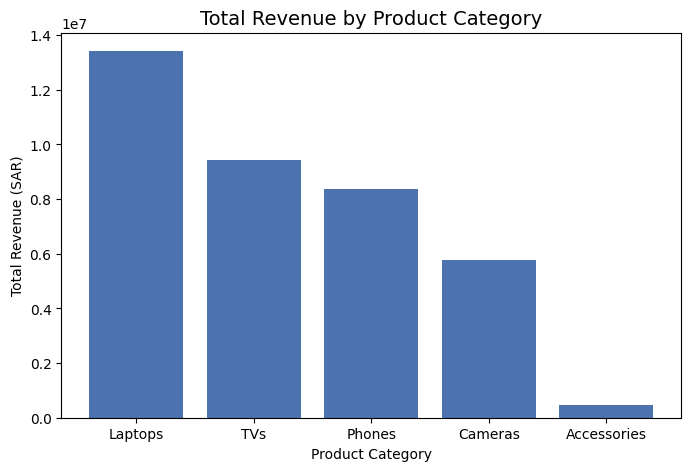

In [ ]:
# --- رسم بياني: إجمالي الإيراد حسب فئة المنتج (بالإنجليزي) ---

plt.figure(figsize=(8, 5))

plt.bar(category_revenue.index, category_revenue.values, color="#4C72B0")

# العناوين والمحاور بالإنجليزي - المعيار المتبع بمجال تحليل البيانات
plt.title("Total Revenue by Product Category", fontsize=14)
plt.xlabel("Product Category")
plt.ylabel("Total Revenue (SAR)")

plt.xticks(rotation=0)
plt.show()

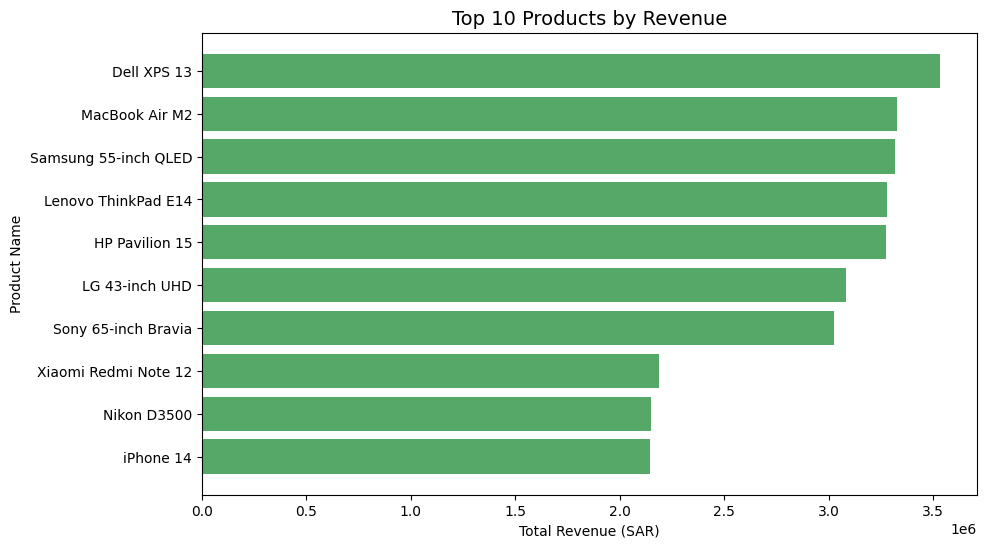

In [ ]:
# --- رسم بياني: أعلى 10 منتجات من حيث الإيراد ---

plt.figure(figsize=(10, 6))

# نرسم Bar Chart أفقي هالمرة (barh بدل bar) لأن أسماء المنتجات طويلة
# ونعكس الترتيب بـ [::-1] عشان أعلى منتج يطلع بالأعلى بالرسمة (مو بالأسفل)
plt.barh(top_products.index[::-1], top_products.values[::-1], color="#55A868")

plt.title("Top 10 Products by Revenue", fontsize=14)
plt.xlabel("Total Revenue (SAR)")
plt.ylabel("Product Name")

plt.show()

In [ ]:
# --- إعادة كتابة نفس الكود بدون تحذير، باستخدام .copy() ---

# .copy() تنشئ نسخة مستقلة تمامًا من الجدول، بدل "إشارة" لجزء من df الأصلي
# هذا يمنع pandas من التشويش هل نعدل على df الأصلي أو على sales_only
sales_only = df[df["OrderType"] == "Sale"].copy()

# الآن نضيف العمود بأمان تام، بدون أي تحذير
sales_only["OrderMonth"] = sales_only["OrderDate"].dt.to_period("M")

# نعيد حساب الإيراد الشهري (نفس الكود اللي قبل)
monthly_revenue = sales_only.groupby("OrderMonth")["TotalAmount"].sum()


print(monthly_revenue)

OrderMonth
2024-01    3153696.990
2024-02    2590261.610
2024-03    3339664.260
2024-04    3074495.880
2024-05    2939117.835
2024-06    3069817.565
2024-07    2879792.500
2024-08    3133082.880
2024-09    3080546.645
2024-10    3438445.920
2024-11    2919909.880
2024-12    3820124.585
Freq: M, Name: TotalAmount, dtype: float64


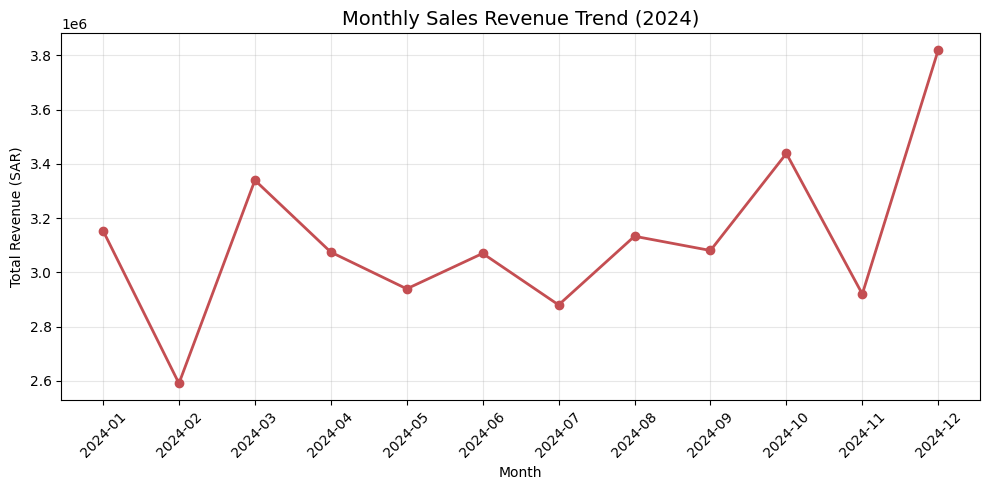

In [ ]:
# --- رسم بياني: الاتجاه الزمني للمبيعات الشهرية ---

plt.figure(figsize=(10, 5))

# نحول index الشهور لنص (str) عشان تترسم بشكل صحيح على المحور الأفقي
# marker='o' يضيف نقطة دائرية واضحة عند كل شهر على الخط
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, marker='o', color="#C44E52", linewidth=2)

plt.title("Monthly Sales Revenue Trend (2024)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Revenue (SAR)")

# ندوّر أسماء الشهور 45 درجة عشان تكون مقروءة بدون تداخل (12 شهر بمساحة محدودة)
plt.xticks(rotation=45)

# نضيف خطوط شبكة خفيفة بالخلفية تسهل قراءة القيم
plt.grid(True, alpha=0.3)

# نضبط المسافات تلقائيًا عشان ما يصير قص بعناوين المحاور
plt.tight_layout()

plt.show()

In [ ]:
# --- سؤال 3: تأثير المرتجعات على صافي الإيراد ---

# 1) إجمالي المبيعات الخام (بس صفوف Sale، بدون خصم أي شي)
total_sales = df[df["OrderType"] == "Sale"]["TotalAmount"].sum()

# 2) إجمالي قيمة المرتجعات (القيمة أصلاً سالبة بعمود TotalAmount، فناخذ القيمة المطلقة للعرض بوضوح)
total_returns = df[df["OrderType"] == "Return"]["TotalAmount"].sum()

# 3) صافي الإيراد الحقيقي = مجموع كل TotalAmount بالجدول كامل (المبيعات موجبة + المرتجعات سالبة تلقائيًا تُخصم)
net_revenue = df["TotalAmount"].sum()

print("=" * 40)
print(f"إجمالي المبيعات الخام:      {total_sales:,.2f} ريال")
print(f"إجمالي قيمة المرتجعات:       {total_returns:,.2f} ريال")
print(f"صافي الإيراد الحقيقي:        {net_revenue:,.2f} ريال")
print("=" * 40)

# نحسب نسبة المرتجعات من إجمالي المبيعات (بالقيمة المطلقة)
return_rate_pct = (abs(total_returns) / total_sales) * 100
print(f"\nنسبة قيمة المرتجعات من إجمالي المبيعات: {return_rate_pct:.2f}%")

# 4) نحسب نسبة المرتجعات بكل فئة (عدد المرتجعات ÷ عدد كل الطلبات بتلك الفئة)
returns_by_category = df.groupby("ProductCategory")["OrderType"].apply(
    lambda x: (x == "Return").sum() / len(x) * 100
).sort_values(ascending=False)

print("\nنسبة المرتجعات (%) بكل فئة:")
print(returns_by_category)

إجمالي المبيعات الخام:      37,438,956.55 ريال
إجمالي قيمة المرتجعات:       -2,317,666.29 ريال
صافي الإيراد الحقيقي:        35,121,290.26 ريال

نسبة قيمة المرتجعات من إجمالي المبيعات: 6.19%

نسبة المرتجعات (%) بكل فئة:
ProductCategory
Cameras        7.579462
Accessories    6.491885
TVs            6.455696
Phones         5.562130
Laptops        4.030227
Name: OrderType, dtype: float64


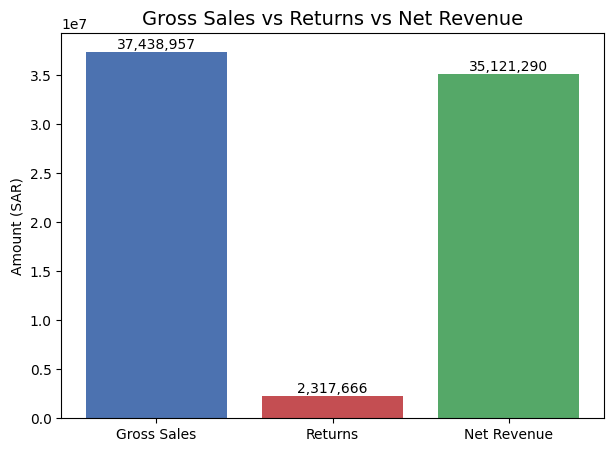

In [ ]:
# --- رسم بياني: مقارنة المبيعات الخام والمرتجعات وصافي الإيراد ---

plt.figure(figsize=(7, 5))

# نجهز 3 قيم للمقارنة: المبيعات، المرتجعات (بالقيمة المطلقة للوضوح البصري)، وصافي الإيراد
labels = ["Gross Sales", "Returns", "Net Revenue"]
values = [total_sales, abs(total_returns), net_revenue]
colors = ["#4C72B0", "#C44E52", "#55A868"]  # أزرق للمبيعات، أحمر للمرتجعات، أخضر للصافي

plt.bar(labels, values, color=colors)

plt.title("Gross Sales vs Returns vs Net Revenue", fontsize=14)
plt.ylabel("Amount (SAR)")

# نضيف القيمة الرقمية فوق كل عمود مباشرة، عشان القارئ ما يحتاج يخمّن من المحور
for i, v in enumerate(values):
    plt.text(i, v + 300000, f"{v:,.0f}", ha='center', fontsize=10)

plt.show()

In [ ]:
# --- سؤال 4: أفضل المناطق من حيث الإيراد ---

# نحسب إجمالي الإيراد بكل منطقة (بس صفوف Sale، بنفس منطق سؤال الفئات)
region_revenue = sales_only.groupby("Region")["TotalAmount"].sum().sort_values(ascending=False)

print("إجمالي الإيراد بكل منطقة (من الأعلى للأقل):")
print(region_revenue)

# نحسب أيضًا عدد الطلبات بكل منطقة (مو بس قيمتها)، عشان نفهم الصورة كاملة
region_orders_count = sales_only.groupby("Region")["OrderID"].count().sort_values(ascending=False)

print("\nعدد الطلبات بكل منطقة:")
print(region_orders_count)

إجمالي الإيراد بكل منطقة (من الأعلى للأقل):
Region
Jeddah           7691281.505
Madinah          7218253.325
Makkah           7103046.195
Riyadh           7031658.100
Dammam           6958085.940
Not Specified    1436631.485
Name: TotalAmount, dtype: float64

عدد الطلبات بكل منطقة:
Region
Jeddah           760
Makkah           745
Riyadh           741
Madinah          714
Dammam           691
Not Specified    153
Name: OrderID, dtype: int64


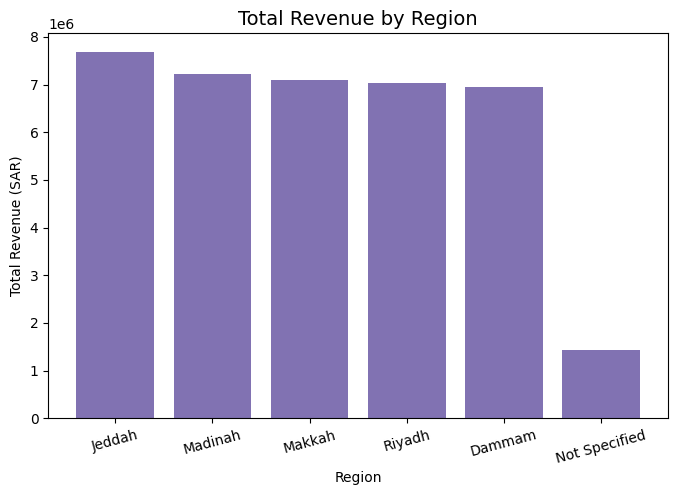

In [ ]:
# --- رسم بياني: إجمالي الإيراد حسب المنطقة ---

plt.figure(figsize=(8, 5))

plt.bar(region_revenue.index, region_revenue.values, color="#8172B2")

plt.title("Total Revenue by Region", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Total Revenue (SAR)")
plt.xticks(rotation=15)

plt.show()